In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

In [2]:
reports_df = pd.read_csv("../archive/indiana_reports.csv")
view_df = pd.read_csv("../archive/indiana_projections.csv")

In [3]:
count = Counter()

for _, row in tqdm(reports_df.iterrows(), total=reports_df.shape[0]):
    problems = row['Problems'].split(";")
    for p in problems:
        count[p] += 1

  0%|          | 0/3851 [00:00<?, ?it/s]

In [4]:
pd.json_normalize(count).T.to_csv("./intermediate/count.csv")

In [5]:
disease_bucket_mapping = {
    # 1. Normal / No Finding
    "normal": "Normal_No_Finding",

    # 2. Cardiomegaly & Cardiovascular Conditions
    "Cardiomegaly": "Cardiomegaly_Cardiovascular",
    "Pulmonary Artery": "Cardiomegaly_Cardiovascular",
    "Cardiac Shadow": "Cardiomegaly_Cardiovascular",
    "Aorta, Thoracic": "Cardiomegaly_Cardiovascular",
    "Aorta": "Cardiomegaly_Cardiovascular",
    "Heart Failure": "Cardiomegaly_Cardiovascular",
    "Epicardial Fat": "Cardiomegaly_Cardiovascular",
    "Heart": "Cardiomegaly_Cardiovascular",
    "Aortic Aneurysm": "Cardiomegaly_Cardiovascular",
    "Heart Atria": "Cardiomegaly_Cardiovascular",
    "Hypertension, Pulmonary": "Cardiomegaly_Cardiovascular",
    "Heart Ventricles": "Cardiomegaly_Cardiovascular",
    "Blood Vessels": "Cardiomegaly_Cardiovascular",
    "Atherosclerosis": "Cardiomegaly_Cardiovascular",
    "Pulmonary Congestion": "Cardiomegaly_Cardiovascular",

    # 3. Alveolar Opacities, Infiltrates & Infections
    "Opacity": "Alveolar_Opacities_Infections",
    "Airspace Disease": "Alveolar_Opacities_Infections",
    "Consolidation": "Alveolar_Opacities_Infections",
    "Infiltrate": "Alveolar_Opacities_Infections",
    "Pulmonary Edema": "Alveolar_Opacities_Infections",
    "Pneumonia": "Alveolar_Opacities_Infections",
    "Bronchitis": "Alveolar_Opacities_Infections",
    "Cavitation": "Alveolar_Opacities_Infections",
    "Bronchiolitis": "Alveolar_Opacities_Infections",

    # 4. Pleural Space Diseases & Pneumothorax
    "Thickening": "Pleural_Space_Pneumothorax",
    "Pleural Effusion": "Pleural_Space_Pneumothorax",
    "Costophrenic Angle": "Pleural_Space_Pneumothorax",
    "Pneumothorax": "Pleural_Space_Pneumothorax",
    "Sulcus": "Pleural_Space_Pneumothorax",
    "Hydropneumothorax": "Pleural_Space_Pneumothorax",
    "Pleura": "Pleural_Space_Pneumothorax",
    "Pericardial Effusion": "Pleural_Space_Pneumothorax",
    "Hemopneumothorax": "Pleural_Space_Pneumothorax",
    "Hemothorax": "Pleural_Space_Pneumothorax",

    # 5. Chronic Obstructive & Hyperinflation Lung Diseases
    "Pulmonary Disease, Chronic Obstructive": "COPD_Hyperinflation",
    "Bullous Emphysema": "COPD_Hyperinflation",
    "Lung, Hyperlucent": "COPD_Hyperinflation",
    "Pulmonary Emphysema": "COPD_Hyperinflation",
    "Emphysema": "COPD_Hyperinflation",
    "Bronchiectasis": "COPD_Hyperinflation",
    "Cystic Fibrosis": "COPD_Hyperinflation",

    # 6. Atelectasis & Volume Loss
    "Pulmonary Atelectasis": "Atelectasis_Volume_Loss",
    "Volume Loss": "Atelectasis_Volume_Loss",
    "Shift": "Atelectasis_Volume_Loss",

    # 7. Nodules, Masses & Chronic Fibrotic/Granulomatous Diseases
    "Pulmonary Fibrosis": "Nodules_Masses_Chronic_Fibrotic",
    "Cicatrix": "Nodules_Masses_Chronic_Fibrotic",
    "Calcified Granuloma": "Nodules_Masses_Chronic_Fibrotic",
    "Granulomatous Disease": "Nodules_Masses_Chronic_Fibrotic",
    "Nodule": "Nodules_Masses_Chronic_Fibrotic",
    "Mass": "Nodules_Masses_Chronic_Fibrotic",
    "Cysts": "Nodules_Masses_Chronic_Fibrotic",
    "Granuloma": "Nodules_Masses_Chronic_Fibrotic",
    "Fibrosis": "Nodules_Masses_Chronic_Fibrotic",
    "Tuberculosis": "Nodules_Masses_Chronic_Fibrotic",
    "Sarcoidosis": "Nodules_Masses_Chronic_Fibrotic",
    "Lymph Nodes": "Nodules_Masses_Chronic_Fibrotic",
    "Lymph nodes": "Nodules_Masses_Chronic_Fibrotic",
    "Lung Diseases, Interstitial": "Nodules_Masses_Chronic_Fibrotic",

    # 8. Spine, Bones & Musculoskeletal Conditions
    "Osteophyte": "Bones_Spine_Musculoskeletal",
    "Spondylosis": "Bones_Spine_Musculoskeletal",
    "Arthritis": "Bones_Spine_Musculoskeletal",
    "Thoracic Vertebrae": "Bones_Spine_Musculoskeletal",
    "Thoracic vertebrae": "Bones_Spine_Musculoskeletal",
    "Bone and Bones": "Bones_Spine_Musculoskeletal",
    "Spine": "Bones_Spine_Musculoskeletal",
    "Scoliosis": "Bones_Spine_Musculoskeletal",
    "Kyphosis": "Bones_Spine_Musculoskeletal",
    "Osteoporosis": "Bones_Spine_Musculoskeletal",
    "Bone Diseases, Metabolic": "Bones_Spine_Musculoskeletal",
    "Dislocations": "Bones_Spine_Musculoskeletal",
    "Shoulder": "Bones_Spine_Musculoskeletal",
    "Spinal Fusion": "Bones_Spine_Musculoskeletal",
    "Expansile Bone Lesions": "Bones_Spine_Musculoskeletal",
    "Fractures, Bone": "Bones_Spine_Musculoskeletal",
    "Lumbar Vertebrae": "Bones_Spine_Musculoskeletal",
    "Sclerosis": "Bones_Spine_Musculoskeletal",
    "Funnel Chest": "Bones_Spine_Musculoskeletal",
    "Cervical Vertebrae": "Bones_Spine_Musculoskeletal",
    "Humerus": "Bones_Spine_Musculoskeletal",
    "Pectus Carinatum": "Bones_Spine_Musculoskeletal",
    "Ribs": "Bones_Spine_Musculoskeletal",
    "Hyperostosis, Diffuse Idiopathic Skeletal": "Bones_Spine_Musculoskeletal",
    "Deformity": "Bones_Spine_Musculoskeletal",

    # 9. Medical Devices & Post-Surgical Support
    "Breast Implants": "Devices_Surgical_Support",
    "Sutures": "Devices_Surgical_Support",
    "Tube, Inserted": "Devices_Surgical_Support",
    "Surgical Instruments": "Devices_Surgical_Support",
    "Stents": "Devices_Surgical_Support",
    "Implanted Medical Device": "Devices_Surgical_Support",
    "Catheters, Indwelling": "Devices_Surgical_Support",
    "Medical Device": "Devices_Surgical_Support",
    "Mastectomy": "Devices_Surgical_Support",
    "Pneumonectomy": "Devices_Surgical_Support",
    "Contrast Media": "Devices_Surgical_Support",

    # 10. Diaphragmatic, Mediastinal & Extrathoracic Alterations
    "Diaphragm": "Diaphragm_Mediastinum_Extrathoracic",
    "Hernia, Hiatal": "Diaphragm_Mediastinum_Extrathoracic",
    "Mediastinum": "Diaphragm_Mediastinum_Extrathoracic",
    "Diaphragmatic Eventration": "Diaphragm_Mediastinum_Extrathoracic",
    "Pneumoperitoneum": "Diaphragm_Mediastinum_Extrathoracic",
    "Trachea": "Diaphragm_Mediastinum_Extrathoracic",
    "Colonic Interposition": "Diaphragm_Mediastinum_Extrathoracic",
    "Cholelithiasis": "Diaphragm_Mediastinum_Extrathoracic",
    "Hernia, Diaphragmatic": "Diaphragm_Mediastinum_Extrathoracic",
    "Trachea, Carina": "Diaphragm_Mediastinum_Extrathoracic",
    "Abdomen": "Diaphragm_Mediastinum_Extrathoracic",
    "Subcutaneous Emphysema": "Diaphragm_Mediastinum_Extrathoracic",
    "Subcutaneous  Emphysema": "Diaphragm_Mediastinum_Extrathoracic",  # Handles the double-space version present in raw data

    # 11. Non-specific Descriptive & Technical Labels
    "Lung": "Non_Specific_Technical",
    "Density": "Non_Specific_Technical",
    "Markings": "Non_Specific_Technical",
    "No Indexing": "Non_Specific_Technical",
    "Calcinosis": "Non_Specific_Technical",
    "Technical Quality of Image Unsatisfactory ": "Non_Specific_Technical",
    "Foreign Bodies": "Non_Specific_Technical",
    "Lucency": "Non_Specific_Technical",
    "Blister": "Non_Specific_Technical",
    "Adipose Tissue": "Non_Specific_Technical",
    "Nipple Shadow": "Non_Specific_Technical",
    "Thorax": "Non_Specific_Technical",
    "Hypovolemia": "Non_Specific_Technical",
}

In [6]:
import numpy as np
import pandas as pd

# Unique ordered list of your 11 targets
target_buckets = sorted(list(set(disease_bucket_mapping.values())))
bucket_to_idx = {bucket: idx for idx, bucket in enumerate(target_buckets)}


def label_to_multi_hot(raw_labels_list):
    """Encodes an array/list of raw string labels into an 11-dimensional vector."""
    vector = np.zeros(len(target_buckets), dtype=np.float32)
    for label in raw_labels_list:
        # print(label)
        if label in disease_bucket_mapping:
            bucket_name = disease_bucket_mapping[label]
            idx = bucket_to_idx[bucket_name]
            vector[idx] = 1.0
    return vector


# Usage Example:
# df['target_vector'] = df['raw_findings_list'].apply(label_to_multi_hot)
print("Target Buckets order for multi-hot encoding vectors:")
for idx, b in enumerate(target_buckets):
    print(f"Index {idx}: {b}")

Target Buckets order for multi-hot encoding vectors:
Index 0: Alveolar_Opacities_Infections
Index 1: Atelectasis_Volume_Loss
Index 2: Bones_Spine_Musculoskeletal
Index 3: COPD_Hyperinflation
Index 4: Cardiomegaly_Cardiovascular
Index 5: Devices_Surgical_Support
Index 6: Diaphragm_Mediastinum_Extrathoracic
Index 7: Nodules_Masses_Chronic_Fibrotic
Index 8: Non_Specific_Technical
Index 9: Normal_No_Finding
Index 10: Pleural_Space_Pneumothorax


In [7]:
def decide_bucket(labels):
    labels = labels.split(";")
    bucket = set()

    for l in labels:
        b = disease_bucket_mapping.get(l, None)
        bucket.add(b)

    return ";".join(bucket)

In [8]:
reports_df['buckets'] = reports_df['Problems'].map(decide_bucket)

In [9]:
reports_df

,uid,MeSH,Problems,image,indication,comparison,findings,impression,buckets
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,Normal_No_Finding
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,Cardiomegaly_Cardiovascular
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p...",Normal_No_Finding
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,Nodules_Masses_Chronic_Fibrotic;COPD_Hyperinfl...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,Pleural_Space_Pneumothorax;Non_Specific_Techni...
...,...,...,...,...,...,...,...,...,...
3846,3995,Lung/hyperdistention/mild;Diaphragm/bilateral/...,Lung;Diaphragm;Cicatrix;Pulmonary Atelectasis;...,Xray Chest PA and Lateral,"Nausea, vomiting x2 weeks. Dialysis patient.","XXXX, XXXX.",The cardiomediastinal silhouette and pulmonary...,1. Interval resolution of bibasilar airspace d...,COPD_Hyperinflation;Non_Specific_Technical;Ate...
3847,3996,Spine/degenerative,Spine,Xray Chest PA and Lateral,NaN,None.,The lungs are clear. Heart size is normal. No ...,Clear lungs. No acute cardiopulmonary abnormal...,Bones_Spine_Musculoskeletal
3848,3997,Opacity/lung/upper lobe/right/round/small;Gran...,Opacity;Granuloma,PA and lateral views of the chest.,XXXX-year-old male with positive PPD.,None available.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB.",Nodules_Masses_Chronic_Fibrotic;Alveolar_Opaci...
3849,3998,normal,normal,"PA and lateral chest XXXX, XXXX XXXX comparis...",tuberculosis positive PPD,NaN,NaN,Heart size is normal and the lungs are clear.,Normal_No_Finding


In [10]:
view_df

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal
...,...,...,...
7461,3997,3997_IM-2048-1002.dcm.png,Lateral
7462,3998,3998_IM-2048-1001.dcm.png,Frontal
7463,3998,3998_IM-2048-1002.dcm.png,Lateral
7464,3999,3999_IM-2049-1001.dcm.png,Frontal


In [11]:
import os

root = "../archive/images/images_normalized/"

view_mapping = defaultdict(lambda : {"F": None, "L": None})

for _, row in tqdm(view_df.iterrows(), total=view_df.shape[0]):
    view_mapping[row['uid']][row['projection'][0]] = os.path.join(root, row['filename'])

  0%|          | 0/7466 [00:00<?, ?it/s]

In [12]:
pd.DataFrame(view_mapping).T

,F,L
1,../archive/images/images_normalized/1_IM-0001-...,../archive/images/images_normalized/1_IM-0001-...
2,../archive/images/images_normalized/2_IM-0652-...,../archive/images/images_normalized/2_IM-0652-...
3,../archive/images/images_normalized/3_IM-1384-...,../archive/images/images_normalized/3_IM-1384-...
4,../archive/images/images_normalized/4_IM-2050-...,../archive/images/images_normalized/4_IM-2050-...
5,../archive/images/images_normalized/5_IM-2117-...,../archive/images/images_normalized/5_IM-2117-...
...,...,...
3995,../archive/images/images_normalized/3995_IM-20...,../archive/images/images_normalized/3995_IM-20...
3996,../archive/images/images_normalized/3996_IM-20...,../archive/images/images_normalized/3996_IM-20...
3997,../archive/images/images_normalized/3997_IM-20...,../archive/images/images_normalized/3997_IM-20...
3998,../archive/images/images_normalized/3998_IM-20...,../archive/images/images_normalized/3998_IM-20...


In [13]:
reports_df['Frontal'] = None
reports_df['Lateral'] = None

for _, row in tqdm(reports_df.iterrows(), total=reports_df.shape[0]):
    reports_df.loc[_, "Frontal"] = view_mapping[row['uid']]['F']
    reports_df.loc[_, "Lateral"] = view_mapping[row['uid']]['L']

  0%|          | 0/3851 [00:00<?, ?it/s]

In [14]:
reports_df

,uid,MeSH,Problems,image,indication,comparison,findings,impression,buckets,Frontal,Lateral
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,Normal_No_Finding,../archive/images/images_normalized/1_IM-0001-...,../archive/images/images_normalized/1_IM-0001-...
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,Cardiomegaly_Cardiovascular,../archive/images/images_normalized/2_IM-0652-...,../archive/images/images_normalized/2_IM-0652-...
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p...",Normal_No_Finding,../archive/images/images_normalized/3_IM-1384-...,../archive/images/images_normalized/3_IM-1384-...
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,Nodules_Masses_Chronic_Fibrotic;COPD_Hyperinfl...,../archive/images/images_normalized/4_IM-2050-...,../archive/images/images_normalized/4_IM-2050-...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,Pleural_Space_Pneumothorax;Non_Specific_Techni...,../archive/images/images_normalized/5_IM-2117-...,../archive/images/images_normalized/5_IM-2117-...
...,...,...,...,...,...,...,...,...,...,...,...
3846,3995,Lung/hyperdistention/mild;Diaphragm/bilateral/...,Lung;Diaphragm;Cicatrix;Pulmonary Atelectasis;...,Xray Chest PA and Lateral,"Nausea, vomiting x2 weeks. Dialysis patient.","XXXX, XXXX.",The cardiomediastinal silhouette and pulmonary...,1. Interval resolution of bibasilar airspace d...,COPD_Hyperinflation;Non_Specific_Technical;Ate...,../archive/images/images_normalized/3995_IM-20...,../archive/images/images_normalized/3995_IM-20...
3847,3996,Spine/degenerative,Spine,Xray Chest PA and Lateral,NaN,None.,The lungs are clear. Heart size is normal. No ...,Clear lungs. No acute cardiopulmonary abnormal...,Bones_Spine_Musculoskeletal,../archive/images/images_normalized/3996_IM-20...,../archive/images/images_normalized/3996_IM-20...
3848,3997,Opacity/lung/upper lobe/right/round/small;Gran...,Opacity;Granuloma,PA and lateral views of the chest.,XXXX-year-old male with positive PPD.,None available.,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB.",Nodules_Masses_Chronic_Fibrotic;Alveolar_Opaci...,../archive/images/images_normalized/3997_IM-20...,../archive/images/images_normalized/3997_IM-20...
3849,3998,normal,normal,"PA and lateral chest XXXX, XXXX XXXX comparis...",tuberculosis positive PPD,NaN,NaN,Heart size is normal and the lungs are clear.,Normal_No_Finding,../archive/images/images_normalized/3998_IM-20...,../archive/images/images_normalized/3998_IM-20...


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


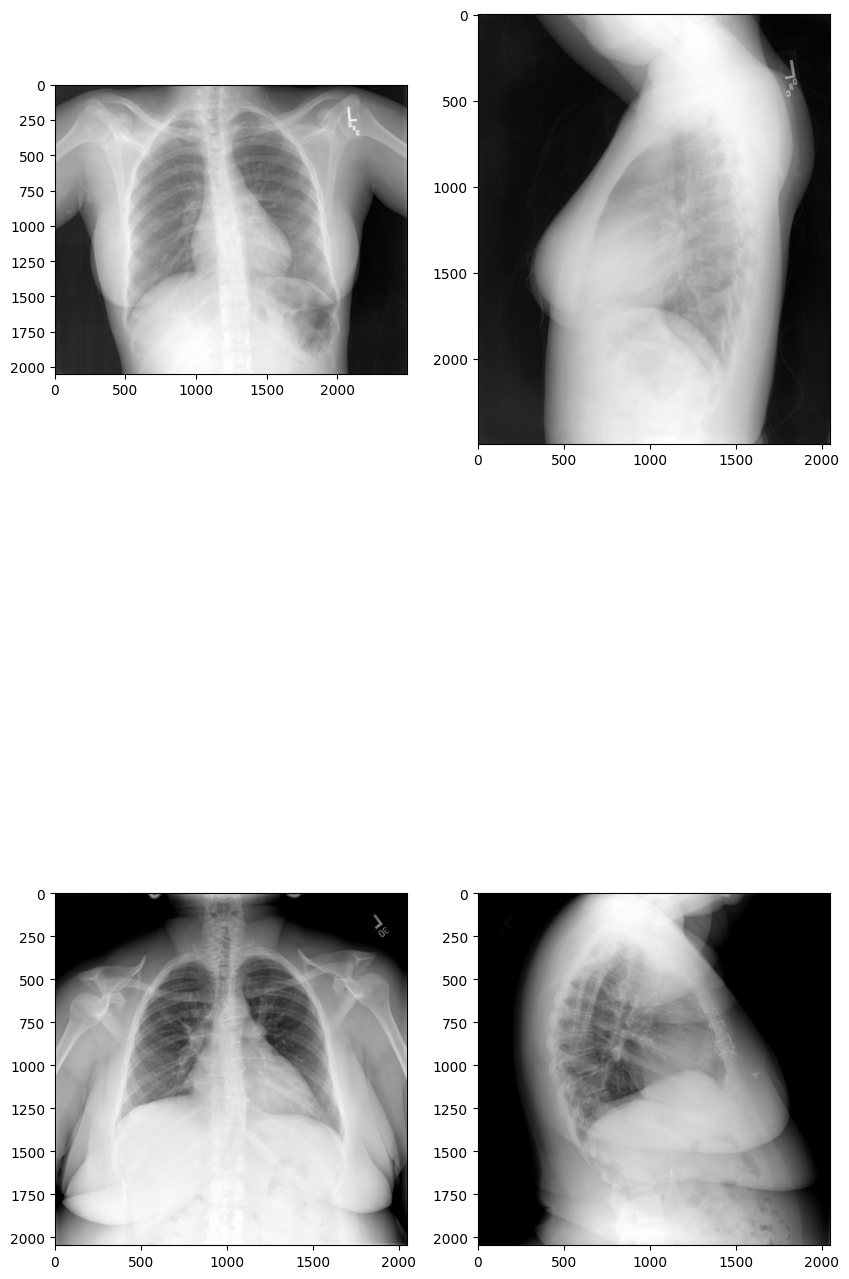

In [22]:
from transformers.image_utils import load_image

fig, axes = plt.subplots(ncols = 2, nrows=2, figsize = (10,20))

axes[0][0].imshow(load_image(reports_df.loc[0, 'Frontal']))
axes[0][1].imshow(load_image(reports_df.loc[0, 'Lateral']))

axes[1][0].imshow(load_image(reports_df.loc[1, 'Frontal']))
axes[1][1].imshow(load_image(reports_df.loc[1, 'Lateral']))

In [24]:
reports_df.to_csv("./intermediate/final_dataset.csv", index=False)

In [32]:
reports_df.loc[100, 'buckets'].split(";")

['Cardiomegaly_Cardiovascular',
 'Bones_Spine_Musculoskeletal',
 'Atelectasis_Volume_Loss',
 'Alveolar_Opacities_Infections',
 'Non_Specific_Technical',
 'Diaphragm_Mediastinum_Extrathoracic']

In [39]:
label_to_multi_hot(reports_df.loc[100, 'Problems'].split(";"))

array([1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0.], dtype=float32)

In [40]:
one_hot_vectors = []

for _, row in reports_df.iterrows():
    problems = row['Problems'].split(";")
    vec = label_to_multi_hot(problems)
    one_hot_vectors.append(vec)

In [42]:
# !pip install iterative-stratification

In [43]:
len(reports_df)

3851

In [44]:
1/ (200 / 3851 )

19.255

In [47]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import numpy as np

mskf = MultilabelStratifiedKFold(n_splits=19, shuffle=True, random_state=108)

X,y = reports_df['uid'].values, np.array(one_hot_vectors)

for train_index, test_index in mskf.split(X,y):
   print("TRAIN:", train_index, "TEST:", test_index)
   X_train, X_test = X[train_index], X[test_index]
   y_train, y_test = y[train_index], y[test_index]

TRAIN: [   0    1    3 ... 3848 3849 3850] TEST: [   2   12   36   41   50   79  106  130  135  168  186  214  235  239
  247  249  250  253  305  328  332  334  352  373  383  384  393  397
  403  418  421  440  443  484  497  500  506  527  528  530  540  565
  570  573  599  617  640  648  653  661  662  681  683  687  707  741
  769  804  814  834  860  912  925  937 1046 1071 1083 1086 1136 1140
 1152 1165 1187 1208 1218 1219 1229 1250 1254 1278 1279 1319 1335 1341
 1349 1350 1383 1411 1430 1437 1457 1468 1479 1504 1568 1580 1592 1597
 1620 1623 1651 1661 1675 1698 1716 1740 1744 1814 1840 1855 1859 1909
 1941 1948 1970 1980 1986 1989 2011 2029 2037 2070 2078 2088 2089 2092
 2112 2121 2125 2146 2161 2172 2239 2307 2315 2317 2342 2347 2382 2405
 2408 2423 2431 2435 2484 2496 2500 2501 2528 2536 2551 2588 2594 2596
 2659 2679 2736 2785 2809 2843 2883 2898 2928 2932 2957 2992 3036 3055
 3062 3074 3075 3084 3102 3133 3137 3173 3174 3182 3197 3203 3205 3217
 3241 3259 3294 3299 3354 33

In [48]:
train_df = reports_df[reports_df['uid'].isin(X_train)]
test_df = reports_df[reports_df['uid'].isin(X_test)]

In [49]:
def split_wise_count(df):
    count = Counter()

    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        buckets = row['buckets'].split(";")
        for b in buckets:
            count[b] += 1
    return pd.json_normalize(count).T

In [54]:
split_wise_count(train_df).sort_values(0)

  0%|          | 0/3653 [00:00<?, ?it/s]

,0
COPD_Hyperinflation,151
Diaphragm_Mediastinum_Extrathoracic,238
Pleural_Space_Pneumothorax,241
Atelectasis_Volume_Loss,310
Devices_Surgical_Support,326
Alveolar_Opacities_Infections,537
Nodules_Masses_Chronic_Fibrotic,637
Cardiomegaly_Cardiovascular,641
Bones_Spine_Musculoskeletal,800
Non_Specific_Technical,1022


In [53]:
split_wise_count(test_df).sort_values(0)

  0%|          | 0/198 [00:00<?, ?it/s]

,0
COPD_Hyperinflation,9
Pleural_Space_Pneumothorax,13
Diaphragm_Mediastinum_Extrathoracic,13
Atelectasis_Volume_Loss,17
Devices_Surgical_Support,18
Alveolar_Opacities_Infections,30
Cardiomegaly_Cardiovascular,36
Nodules_Masses_Chronic_Fibrotic,36
Bones_Spine_Musculoskeletal,45
Non_Specific_Technical,57


In [55]:
print(len(train_df), len(test_df))

3653 198


In [58]:
train_df.to_csv("intermediate/train.csv", index=False)
test_df.to_csv("intermediate/test.csv", index=False)

In [57]:
reports_df.columns

Index(['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison',
       'findings', 'impression', 'buckets', 'Frontal', 'Lateral'],
      dtype='str')

In [1]:
import pandas as pd

df = pd.read_csv("intermediate/train.csv")

In [2]:
df['buckets'].value_counts()

buckets
Normal_No_Finding                                                                                                                                1306
Non_Specific_Technical                                                                                                                            278
Bones_Spine_Musculoskeletal                                                                                                                       237
Nodules_Masses_Chronic_Fibrotic                                                                                                                   163
Cardiomegaly_Cardiovascular                                                                                                                       103
                                                                                                                                                 ... 
Non_Specific_Technical;Pleural_Space_Pneumothorax;Cardiomegaly_Cardiovascular               

In [7]:
from collections import Counter
from tqdm.notebook import tqdm

def split_wise_count(df):
    count = Counter()

    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        buckets = row['buckets'].split(";")
        for b in buckets:
            count[b] += 1
    return pd.json_normalize(count).T

In [8]:
split_wise_count(df)

  0%|          | 0/3653 [00:00<?, ?it/s]

,0
Normal_No_Finding,1306
Cardiomegaly_Cardiovascular,641
Alveolar_Opacities_Infections,537
COPD_Hyperinflation,151
Nodules_Masses_Chronic_Fibrotic,637
Bones_Spine_Musculoskeletal,800
Pleural_Space_Pneumothorax,241
Non_Specific_Technical,1022
Atelectasis_Volume_Loss,310
Devices_Surgical_Support,326


In [10]:
over_sample_dict = {
    "COPD_Hyperinflation": 4,
    "Pleural_Space_Pneumothorax": 4,
    "Atelectasis_Volume_Loss": 3,
    "Devices_Surgical_Support": 2,
    "Diaphragm_Mediastinum_Extrathoracic": 3
}

In [11]:
df['buckets']

0                                       Normal_No_Finding
1                             Cardiomegaly_Cardiovascular
2                                       Normal_No_Finding
3       Alveolar_Opacities_Infections;COPD_Hyperinflat...
4       Bones_Spine_Musculoskeletal;Pleural_Space_Pneu...
                              ...                        
3648                          Cardiomegaly_Cardiovascular
3649    Nodules_Masses_Chronic_Fibrotic;Atelectasis_Vo...
3650                          Bones_Spine_Musculoskeletal
3651    Alveolar_Opacities_Infections;Nodules_Masses_C...
3652                                    Normal_No_Finding
Name: buckets, Length: 3653, dtype: str

In [19]:
sub_dfs = []
for bucket in over_sample_dict:
    sub_df = df[df['buckets'].map(lambda x : bucket in x)]
    abnormal_X = over_sample_dict[bucket]
    print(len(sub_df))
    sub_df = pd.concat([sub_df] * abnormal_X, ignore_index=True)
    sub_dfs.append(sub_df)

final_list = [df] + sub_dfs
final_df = pd.concat(final_list, ignore_index=True)

151
241
310
326
238


In [20]:
len(final_df)

7517

In [21]:
final_df['buckets'].value_counts()

buckets
Normal_No_Finding                                                                                                        1306
Non_Specific_Technical                                                                                                    278
Bones_Spine_Musculoskeletal                                                                                               237
Devices_Surgical_Support                                                                                                  234
Nodules_Masses_Chronic_Fibrotic                                                                                           163
                                                                                                                         ... 
Alveolar_Opacities_Infections;Nodules_Masses_Chronic_Fibrotic;Cardiomegaly_Cardiovascular                                   1
Alveolar_Opacities_Infections;Bones_Spine_Musculoskeletal;Cardiomegaly_Cardiovascular;Non_Specific_Technical  

In [22]:
split_wise_count(final_df)

  0%|          | 0/7517 [00:00<?, ?it/s]

,0
Normal_No_Finding,1306
Cardiomegaly_Cardiovascular,1867
Alveolar_Opacities_Infections,2048
COPD_Hyperinflation,979
Nodules_Masses_Chronic_Fibrotic,1574
Bones_Spine_Musculoskeletal,2003
Pleural_Space_Pneumothorax,1669
Non_Specific_Technical,2842
Atelectasis_Volume_Loss,1837
Devices_Surgical_Support,1448


In [23]:
final_df.to_csv("intermediate/train_v2.csv")